In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('/home/username/D/Machiene Learning Books/CloudExify/sales_data.csv')

In [2]:
print('\n\nFirst 5 Rows\n\n')
print(data.head())
print('\n\nData Shape\n\n')
print(data.shape)
print('\n\nData Info\n\n')
print(data.info())
print('\n\nSatistical Summary\n\n')
print(data.describe())



First 5 Rows


   Row ID        Order ID        Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0  

In [3]:
print('\n\nMissing Values per column:\n',data.isnull().sum())

data = data.dropna()
data = data.drop_duplicates()

data['Date'] = pd.to_datetime(data['Date'])

print('\nCleaned Data Types:\n', data.dtypes)



Missing Values per column:
 Row ID           0
Order ID         0
Date             0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product          0
Amount           0
Units            0
Discount         0
Profit           0
dtype: int64

Cleaned Data Types:
 Row ID                    int64
Order ID                 object
Date             datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product                 

In [4]:
print('Exploratory Analysis Insights\n')
print(f'Total Revenue: Rs {data['Amount'].sum()}')
print(f'Average Sale: Rs {data['Amount'].mean()}')
print(f'Median Sale: Rs {data['Amount'].median()}')
print(f'Standard Deviation: Rs {data['Amount'].std()}')

print('\nProduct Sales Frequency\n')
print(data['Product'].value_counts())

print('Top 10 Products by Revenue')
byProduct = data.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(byProduct.head(10))

Exploratory Analysis Insights

Total Revenue: Rs 2297200.8603
Average Sale: Rs 229.85800083049827
Median Sale: Rs 54.489999999999995
Standard Deviation: Rs 623.2451005086808

Product Sales Frequency

Product
Staple envelope                                           48
Staples                                                   46
Easy-staple paper                                         46
Avery Non-Stick Binders                                   20
Staples in misc. colors                                   19
                                                          ..
Acco Glide Clips                                           1
Cisco 8961 IP Phone Charcoal                               1
Eureka Hand Vacuum, Bagless                                1
LG G2                                                      1
Eldon Jumbo ProFile Portable File Boxes Graphite/Black     1
Name: count, Length: 1850, dtype: int64
Top 10 Products by Revenue
Product
Canon imageCLASS 2200 Advanced Copier         

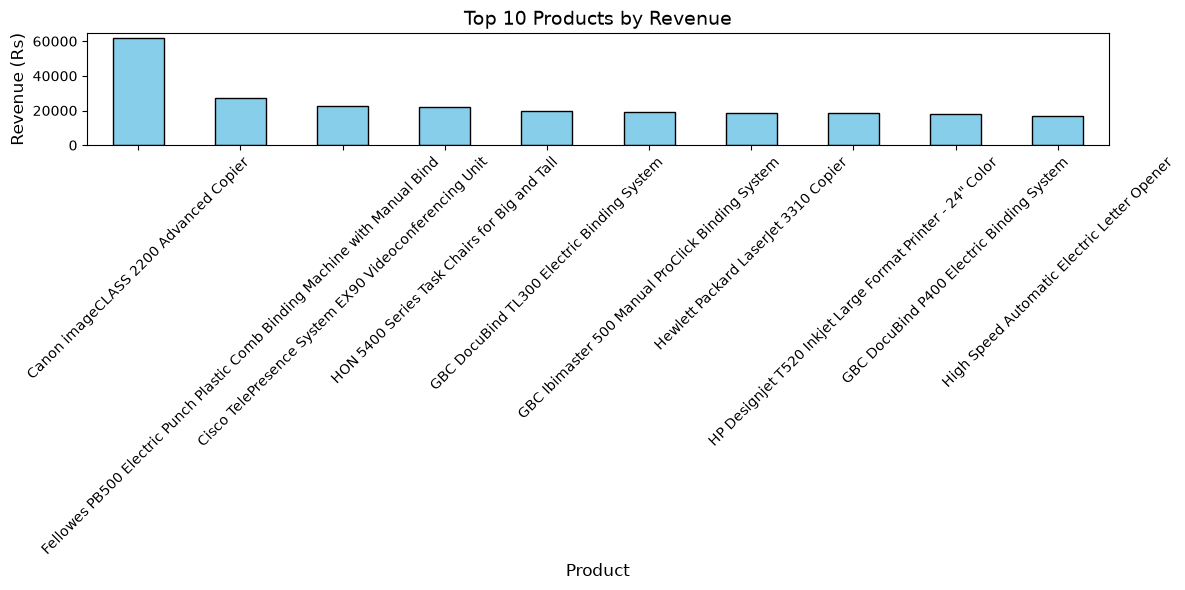

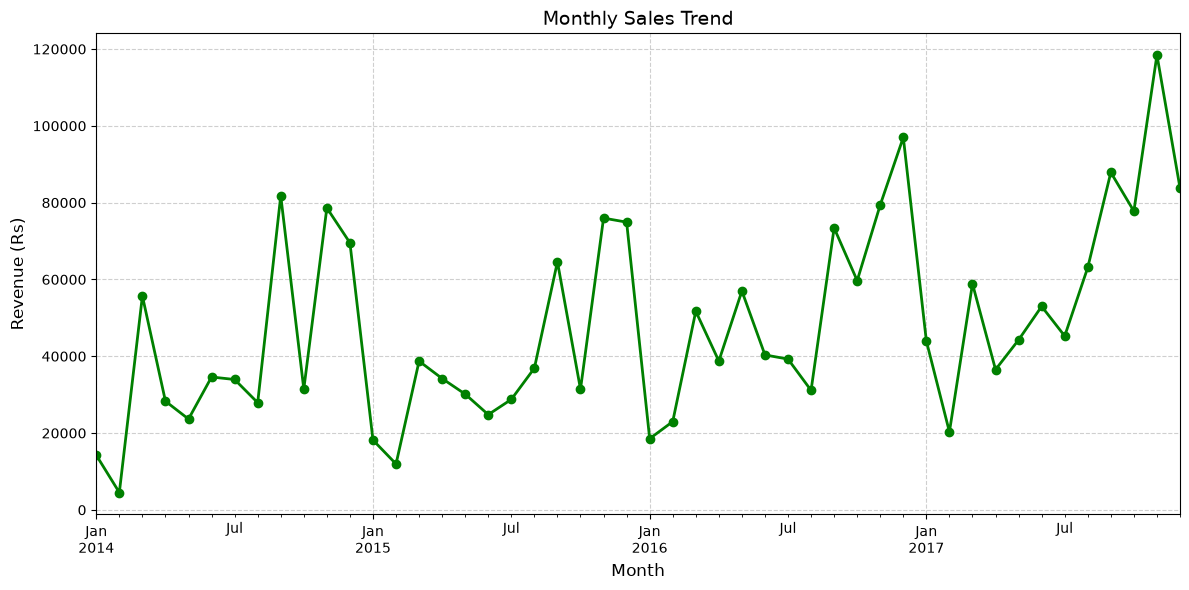

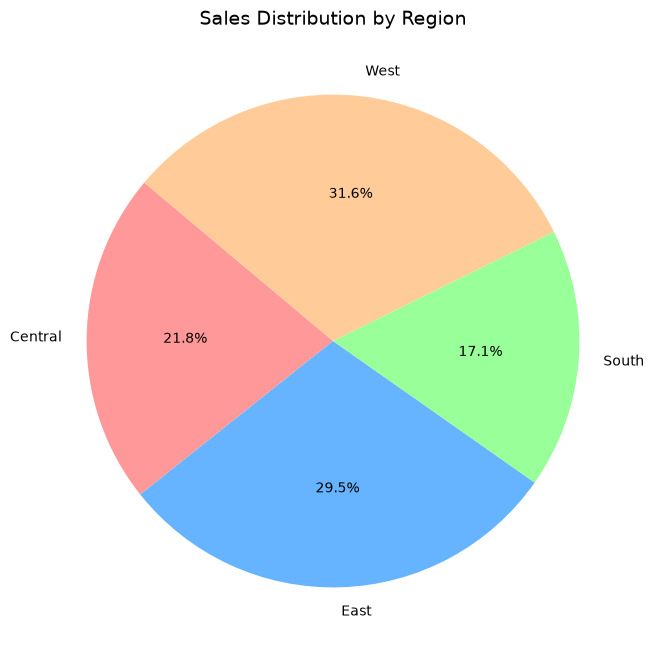


--- Category Comparison ---
                      Amount  Units
Category                           
Furniture        741999.7953   8028
Office Supplies  719047.0320  22906
Technology       836154.0330   6939


In [5]:
plt.figure(figsize=(12, 6))
top_products = data.groupby('Product')['Amount'].sum().nlargest(10)
top_products.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue (Rs)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
monthly_sales = data.groupby(data['Date'].dt.to_period('M'))['Amount'].sum()
monthly_sales.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (Rs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 8))
by_region = data.groupby('Region')['Amount'].sum()
by_region.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Sales Distribution by Region', fontsize=14)
plt.ylabel('') 
plt.show()


by_category = data.groupby('Category').agg({
    'Amount': 'sum',
    'Units': 'sum'
})
print("\n--- Category Comparison ---")
print(by_category)

In [6]:
print('SALES ANALYSIS REPORT')
print(f"Total Records Analyzed : {len(data)}")
print(f"Date Range             : {data['Date'].min().strftime('%Y-%m-%d')} to {data['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Revenue Generated: Rs {data['Amount'].sum()}")
print(f"Average Sale Value     : Rs {data['Amount'].mean()}")
print(f"Median Sale Value      : Rs {data['Amount'].median()}")

print('\nTop 5 Products by Revenue')
print(data.groupby('Product')['Amount'].sum().nlargest(5).apply(lambda x: f"Rs {x}"))

print('\nBest Performing Month')
best_month = data.groupby(data['Date'].dt.to_period('M'))['Amount'].sum().idxmax()
best_month_val = data.groupby(data['Date'].dt.to_period('M'))['Amount'].sum().max()
print(f"Month: {best_month} (Revenue: Rs {best_month_val})")

SALES ANALYSIS REPORT
Total Records Analyzed : 9994
Date Range             : 2014-01-03 to 2017-12-30
Total Revenue Generated: Rs 2297200.8603
Average Sale Value     : Rs 229.85800083049827
Median Sale Value      : Rs 54.489999999999995

Top 5 Products by Revenue
Product
Canon imageCLASS 2200 Advanced Copier                                                   Rs 61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    Rs 27453.384000000002
Cisco TelePresence System EX90 Videoconferencing Unit                                    Rs 22638.48
HON 5400 Series Task Chairs for Big and Tall                                            Rs 21870.576
GBC DocuBind TL300 Electric Binding System                                              Rs 19823.479
Name: Amount, dtype: object

Best Performing Month
Month: 2017-11 (Revenue: Rs 118447.825)
